In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

os.makedirs("../../results/week6", exist_ok=True)

df = pd.read_csv("../../data/ckd.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [6]:
print("=" * 50)
print("CKD Dataset Shape")
print("=" * 50)

print(f"Number of Samples : {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

CKD Dataset Shape
Number of Samples : 400
Number of Features: 25


In [7]:
print("First Five Records")
df.head()

First Five Records


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [8]:
print("Last Five Records")
df.tail()

Last Five Records


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd
399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,131.0,...,53.0,6800.0,6.1,no,no,no,good,no,no,notckd


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

In [10]:
datatype_summary = pd.DataFrame({
    "Feature": df.columns,
    "Datatype": df.dtypes.astype(str)
})

datatype_summary

,Feature,Datatype
age,age,float64
bp,bp,float64
sg,sg,float64
al,al,float64
su,su,float64
rbc,rbc,str
pc,pc,str
pcc,pcc,str
ba,ba,str
bgr,bgr,float64


In [11]:
datatype_summary.to_csv(
    "../../results/week6/ckd_datatypes.csv",
    index=False
)

In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicate rows...")
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

Duplicate Rows: 0
No duplicate rows found.


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [14]:
summary = df.describe().T

summary.to_csv(
    "../../results/week6/ckd_statistical_summary.csv"
)

summary

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
bp,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
sg,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
al,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
su,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
bgr,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
bu,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
sc,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
sod,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000
pot,312.0,4.627244,3.193904,2.500,3.80,4.40,4.90,47.000


In [15]:
missing_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_summary

,Feature,Missing Values,Percentage (%)
rbc,rbc,152,38.00
rbcc,rbcc,131,32.75
wbcc,wbcc,106,26.50
pot,pot,88,22.00
sod,sod,87,21.75
pcv,pcv,71,17.75
pc,pc,65,16.25
hemo,hemo,52,13.00
su,su,49,12.25
sg,sg,47,11.75


In [16]:
missing_summary.to_csv(
    "../../results/week6/ckd_missing_summary.csv",
    index=False
)

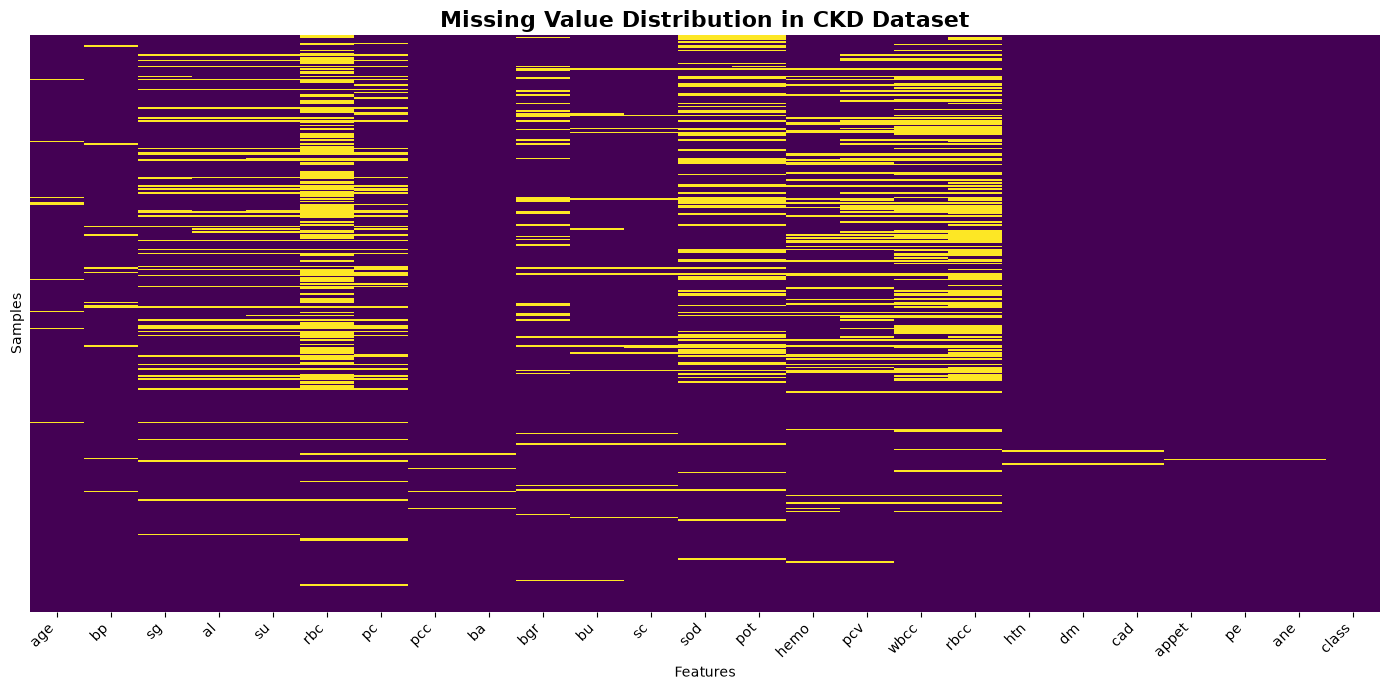

In [17]:
plt.figure(figsize=(14,7))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title(
    "Missing Value Distribution in CKD Dataset",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Features")
plt.ylabel("Samples")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_missing_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

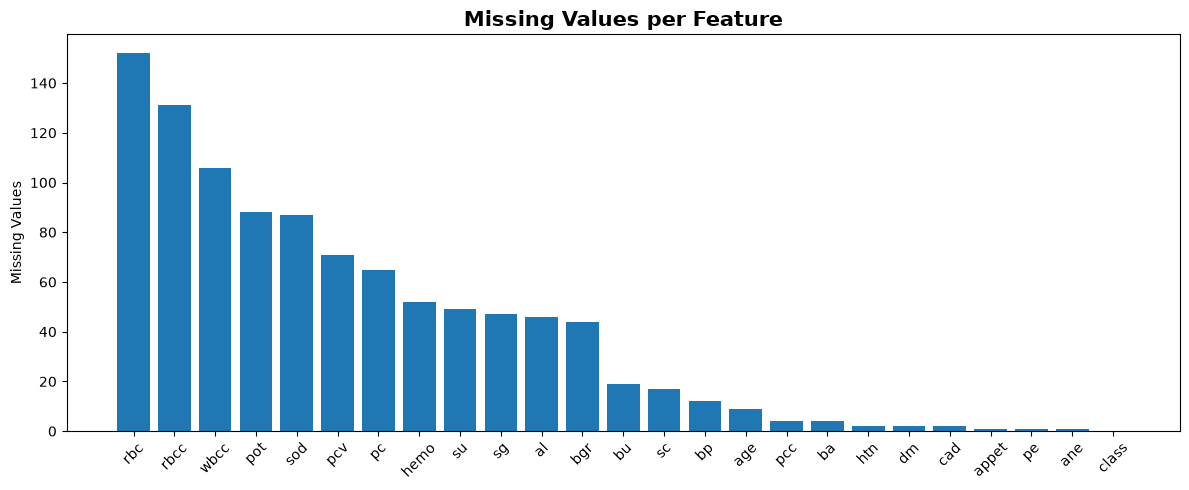

In [18]:
plt.figure(figsize=(12,5))

plt.bar(
    missing_summary["Feature"],
    missing_summary["Missing Values"]
)

plt.title(
    "Missing Values per Feature",
    fontsize=15,
    weight="bold"
)

plt.xticks(rotation=45)

plt.ylabel("Missing Values")

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_missing_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

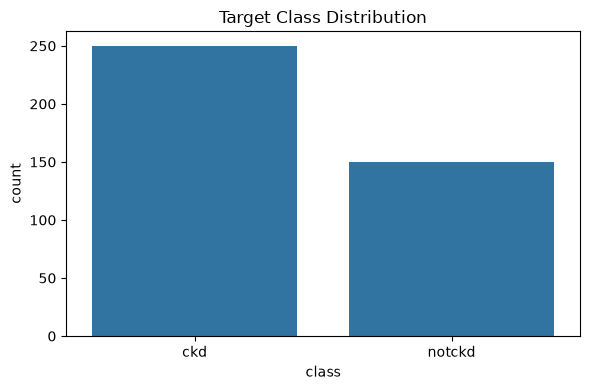

In [19]:
target = df.columns[-1]

plt.figure(figsize=(6,4))

sns.countplot(
    x=df[target]
)

plt.title("Target Class Distribution")

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
print(df[target].value_counts())

class
ckd       250
notckd    150
Name: count, dtype: int64


In [21]:
class_percentage = (
    df[target]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

class_percentage

class
ckd       62.5
notckd    37.5
Name: proportion, dtype: float64

In [22]:
class_percentage.to_csv(
    "../../results/week6/ckd_class_percentage.csv"
)

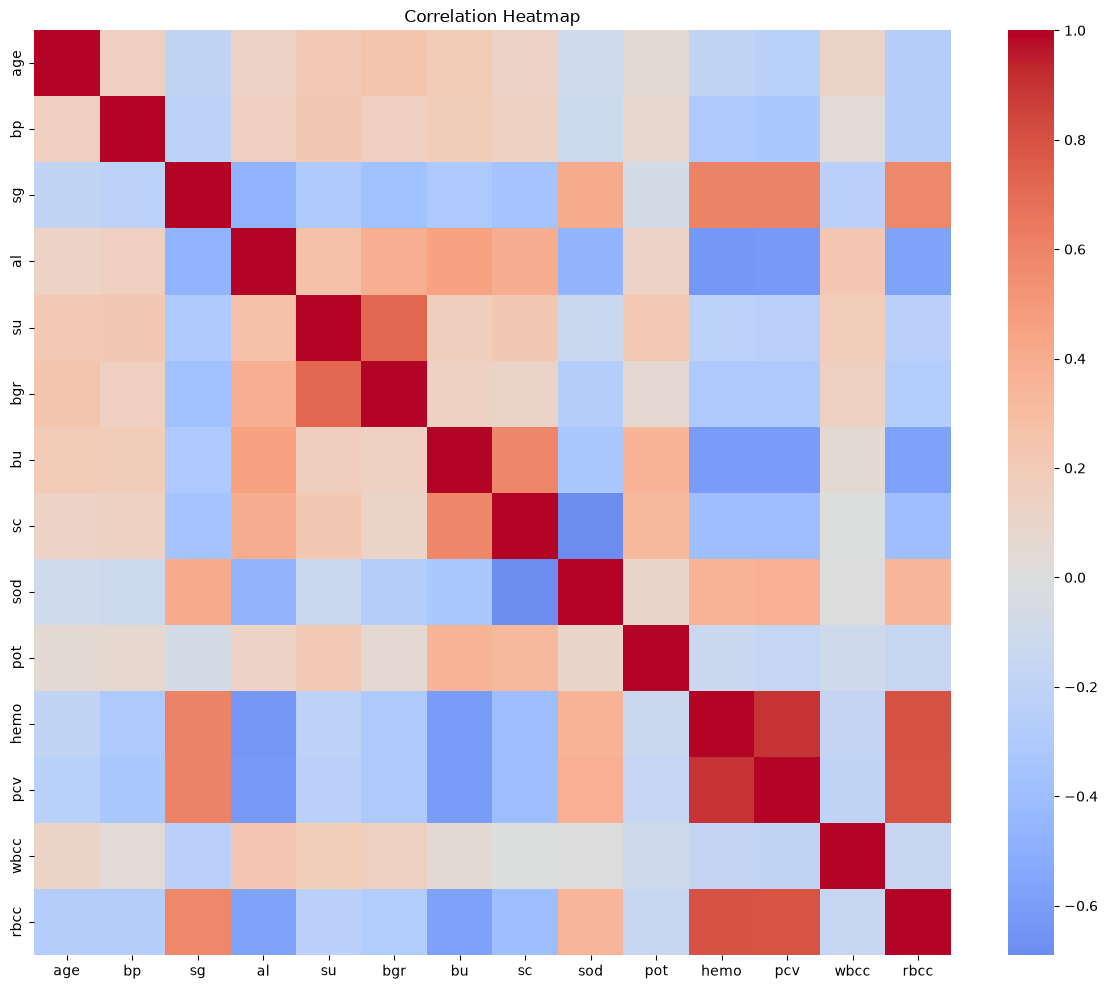

In [23]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_correlation_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [24]:
corr.round(2)

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
age,1.00,0.16,-0.19,0.12,0.22,0.24,0.20,0.13,-0.10,0.06,-0.19,-0.24,0.12,-0.27
bp,0.16,1.00,-0.22,0.16,0.22,0.16,0.19,0.15,-0.12,0.08,-0.31,-0.33,0.03,-0.26
sg,-0.19,-0.22,1.00,-0.47,-0.30,-0.37,-0.31,-0.36,0.41,-0.07,0.60,0.60,-0.24,0.58
al,0.12,0.16,-0.47,1.00,0.27,0.38,0.45,0.40,-0.46,0.13,-0.63,-0.61,0.23,-0.57
su,0.22,0.22,-0.30,0.27,1.00,0.72,0.17,0.22,-0.13,0.22,-0.22,-0.24,0.18,-0.24
bgr,0.24,0.16,-0.37,0.38,0.72,1.00,0.14,0.11,-0.27,0.07,-0.31,-0.30,0.15,-0.28
bu,0.20,0.19,-0.31,0.45,0.17,0.14,1.00,0.59,-0.32,0.36,-0.61,-0.61,0.05,-0.58
sc,0.13,0.15,-0.36,0.40,0.22,0.11,0.59,1.00,-0.69,0.33,-0.40,-0.40,-0.01,-0.40
sod,-0.10,-0.12,0.41,-0.46,-0.13,-0.27,-0.32,-0.69,1.00,0.10,0.37,0.38,0.01,0.34
pot,0.06,0.08,-0.07,0.13,0.22,0.07,0.36,0.33,0.10,1.00,-0.13,-0.16,-0.11,-0.16


In [25]:
corr.to_csv(
    "../../results/week6/ckd_correlation_matrix.csv"
)

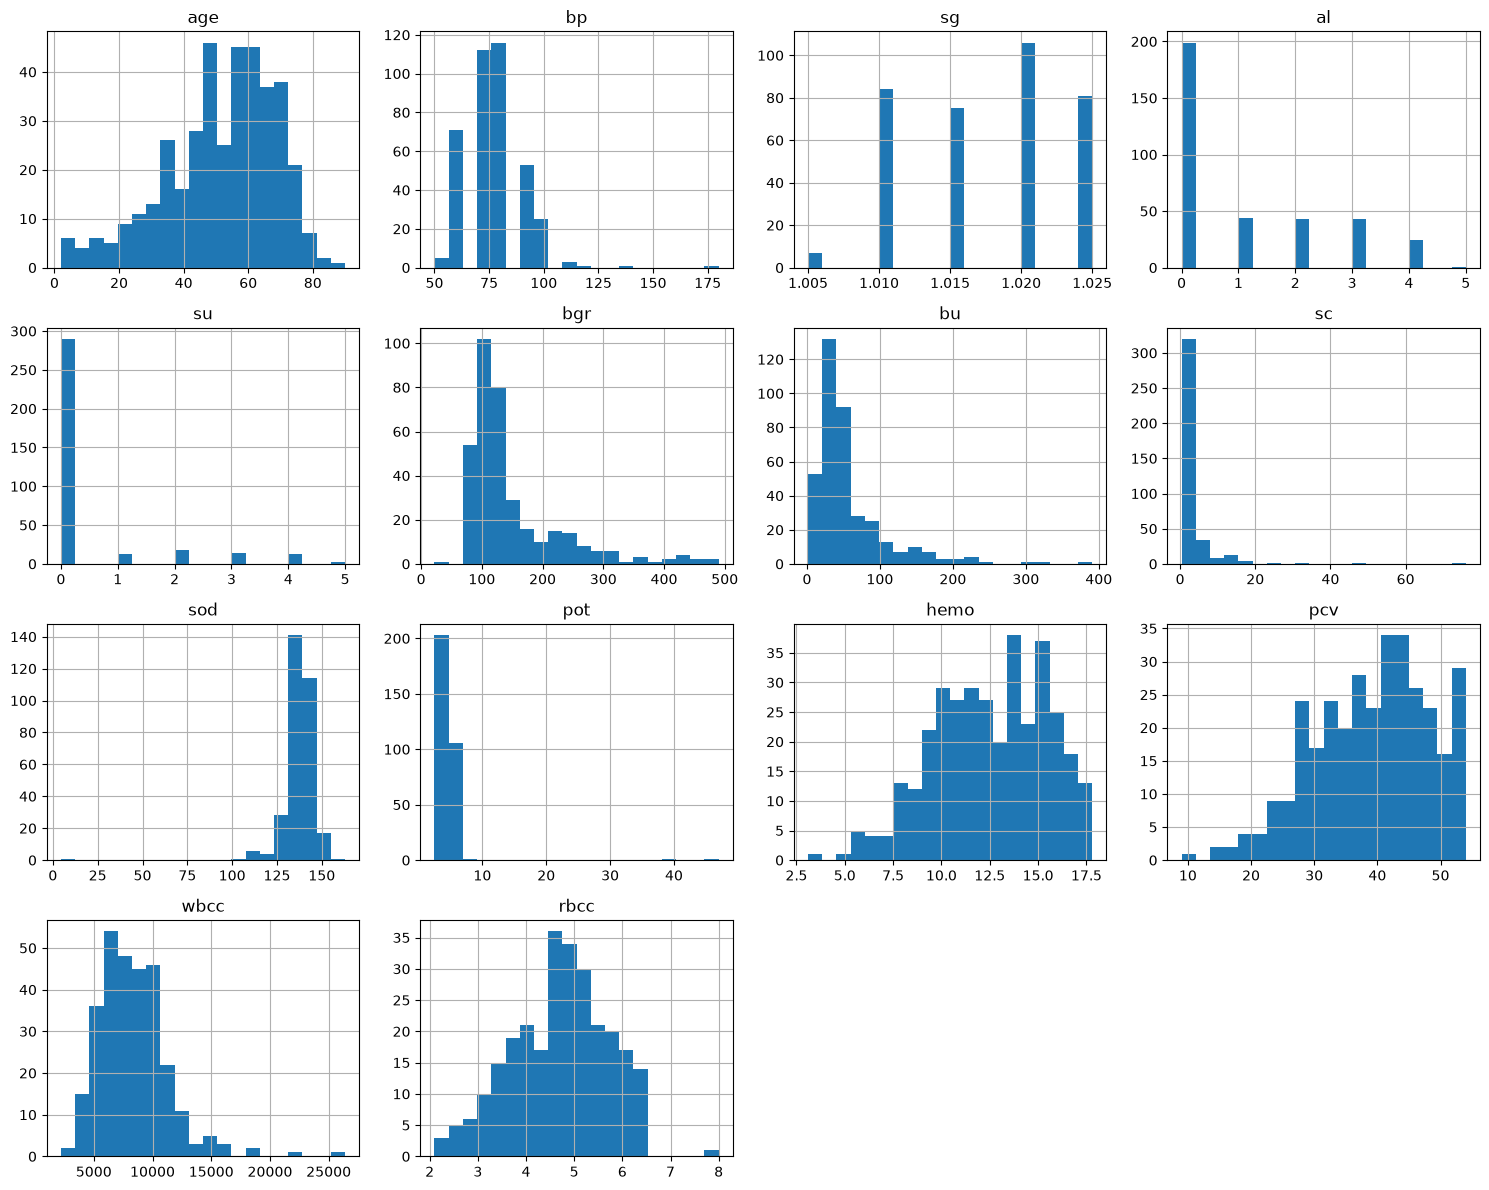

In [26]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

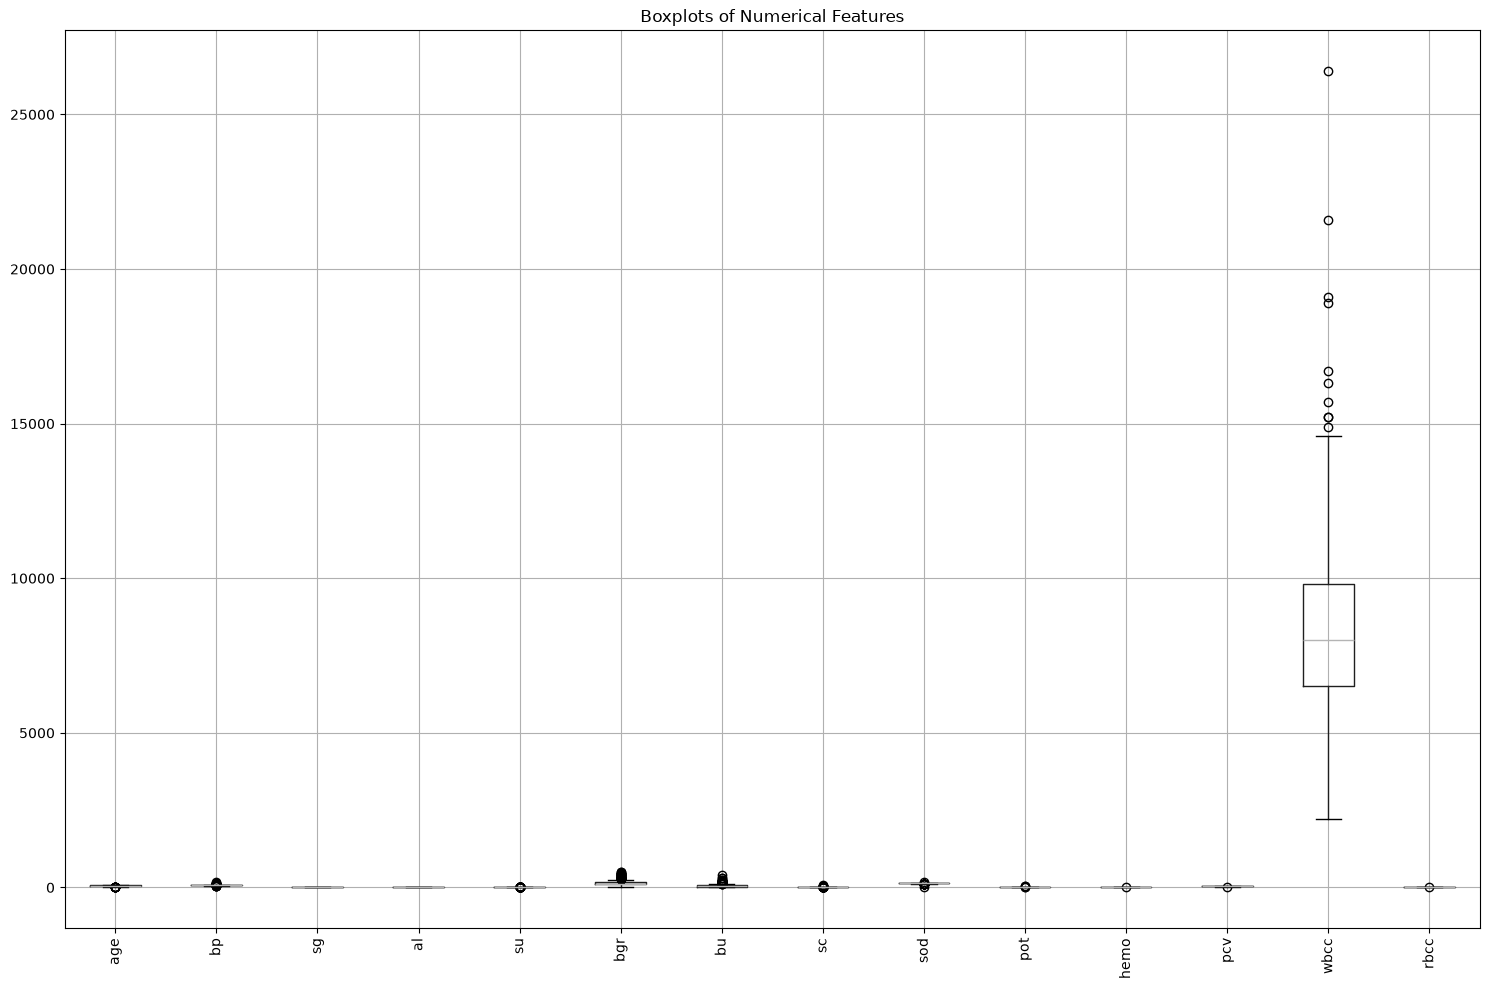

In [27]:
plt.figure(figsize=(15,10))

df[numeric_columns].boxplot(
    rot=90
)

plt.title("Boxplots of Numerical Features")

plt.tight_layout()

plt.savefig(
    "../../results/week6/ckd_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
eda_summary = pd.DataFrame({
    "Analysis": [
        "Dataset Overview",
        "Data Types",
        "Duplicate Check",
        "Missing Values",
        "Target Distribution",
        "Correlation Analysis",
        "Feature Distribution",
        "Outlier Analysis"
    ],
    "Status": [
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]
})

eda_summary

,Analysis,Status
0,Dataset Overview,Completed
1,Data Types,Completed
2,Duplicate Check,Completed
3,Missing Values,Completed
4,Target Distribution,Completed
5,Correlation Analysis,Completed
6,Feature Distribution,Completed
7,Outlier Analysis,Completed


In [29]:
eda_summary.to_csv(
    "../../results/week6/ckd_eda_summary.csv",
    index=False
)